# Empirical Mode Decomposition 2D (EMD2D)

**EMD2D** is the bidimensional counterpart of classical Huang EMD: a single
grayscale image is sifted by interpolating spatial extrema into upper / lower
envelopes (mirror padding + bivariate spline) and subtracting their mean.

PySDKit follows the `PyEMD` implementation
([`EMD2d.py`](https://github.com/laszukdawid/PyEMD/blob/master/PyEMD/EMD2d.py)).

## EMD2D vs BMEMD

Both operate on **images**, but they solve different problems.

| | **EMD2D** (this notebook) | **BMEMD** |
|---|---|---|
| Input | One grayscale image `(H, W)` | Multi-channel stack `(C, H, W)`, `2 <= C <= 16` |
| Output | `(K, H, W)` | `(K, C, H, W)` (last slice = residue) |
| Lineage | 2-D Huang EMD (PyEMD / Laszuk) | 2-D **MEMD** (Xia et al., 2019) |
| Extrema | On the image itself | On **projected** scalar surfaces |
| Envelope | Mirror padding + `SmoothBivariateSpline` | Shared extrema + Clough–Tocher (Delaunay) |
| Channel alignment | N/A (single image) | All channels share the same BIMF count / scales |
| Extra | — | `fuse()` multi-scale image fusion |

Use **EMD2D** for one texture or grayscale field. Use **BMEMD**
(`examples/image/bmemd.ipynb`) when several co-registered images must be
decomposed **jointly** (RGB, multi-sensor, multi-modal fusion). Independent
per-channel EMD2D does **not** keep IMF indices aligned across channels.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import EMD2D
from pysdkit.data import test_univariate_image
from pysdkit.plot import plot_grayscale_image

print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(EMD2D())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Empirical Mode Decomposition 2D (EMD2D)


## 2. Synthetic test image

A compact field (smooth trend + two spatial oscillations), similar to the
FAEMD2D / EMD2D unit tests.  A modest size keeps spline sifting interactive.


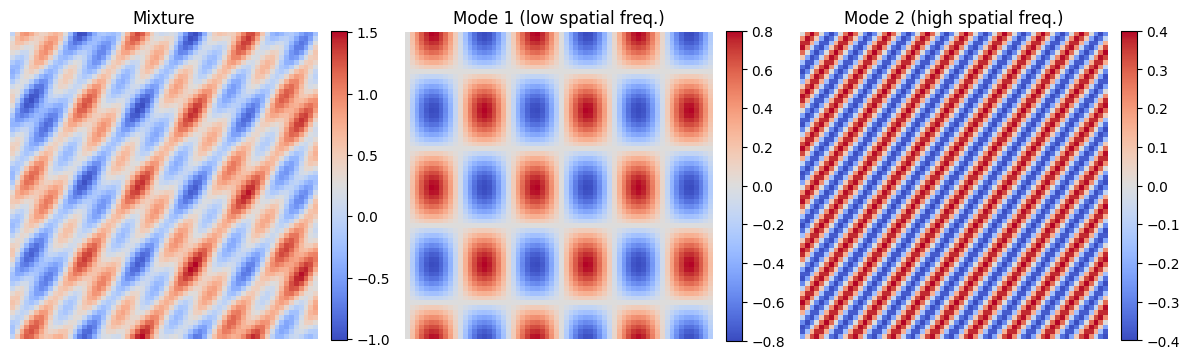

In [2]:
n = 64
yy, xx = np.mgrid[0:n, 0:n]
xx = xx / float(n)
yy = yy / float(n)

trend = 0.3 * xx + 0.2 * yy
mode1 = 0.8 * np.sin(2 * np.pi * 3 * xx) * np.cos(2 * np.pi * 2 * yy)
mode2 = 0.4 * np.sin(2 * np.pi * 8 * xx + 2 * np.pi * 6 * yy)
image = trend + mode1 + mode2

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for ax, data, title in zip(
    axes,
    [image, mode1, mode2],
    ["Mixture", "Mode 1 (low spatial freq.)", "Mode 2 (high spatial freq.)"],
):
    im = ax.imshow(data, cmap="coolwarm")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 3. Run EMD2D and visualise IMFs

`fit_transform` returns an array of shape `(K, H, W)`.  The last slice is the
residue (trend).  Summing all slices reconstructs the input.


IMFs shape: (2, 64, 64)
max |reconstruction error|: 4.440892098500626e-16


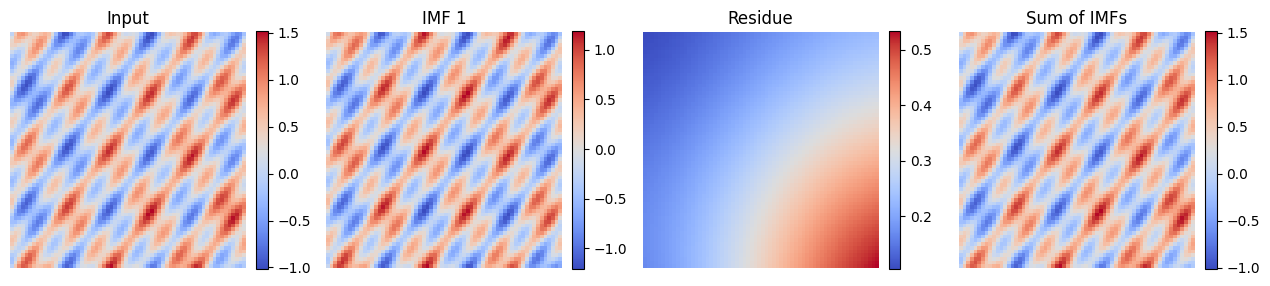

In [3]:
emd2d = EMD2D(max_imfs=4, mse_thr=0.01, mean_thr=0.01, max_iter=80)
IMFs = emd2d.fit_transform(image)
print("IMFs shape:", IMFs.shape)

recon = IMFs.sum(axis=0)
print("max |reconstruction error|:", np.max(np.abs(recon - image)))

n_imf = IMFs.shape[0]
fig, axes = plt.subplots(1, n_imf + 2, figsize=(3.2 * (n_imf + 2), 3.2))
panels = [image, *IMFs, recon]
titles = (
    ["Input"] + [f"IMF {k + 1}" for k in range(n_imf - 1)] + ["Residue", "Sum of IMFs"]
)
for ax, data, title in zip(axes, panels, titles):
    im = ax.imshow(data, cmap="coolwarm")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 4. Extrema maps used for envelope sifting

`find_extrema` locates interior spatial maxima / minima (a 3×3 neighbourhood,
image border excluded).  These points feed `extract_max_min_spline`.


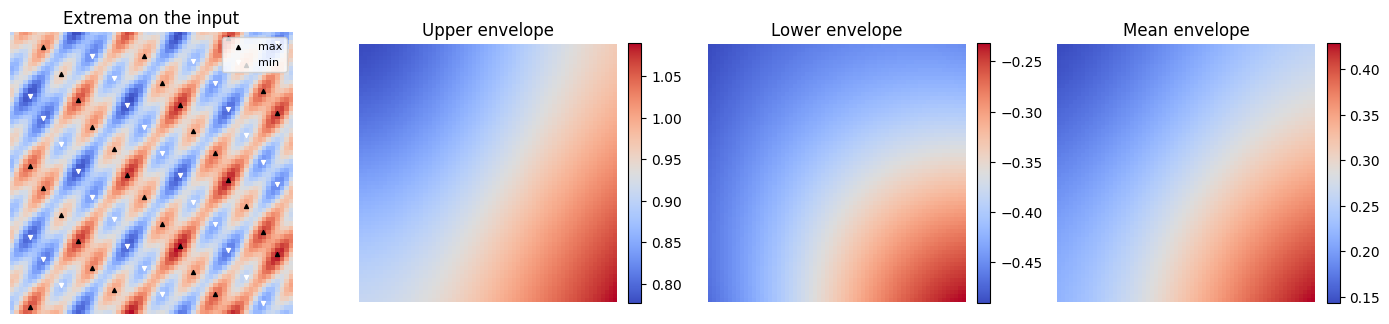

In [4]:
min_peaks, max_peaks = EMD2D.find_extrema(image)
min_env, max_env = emd2d.extract_max_min_spline(image)
mean_env = 0.5 * (min_env + max_env)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.4))
axes[0].imshow(image, cmap="coolwarm")
axes[0].scatter(max_peaks[1], max_peaks[0], s=8, c="k", marker="^", label="max")
axes[0].scatter(min_peaks[1], min_peaks[0], s=8, c="w", marker="v", label="min")
axes[0].set_title("Extrema on the input")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].axis("off")

for ax, data, title in zip(
    axes[1:],
    [max_env, min_env, mean_env],
    ["Upper envelope", "Lower envelope", "Mean envelope"],
):
    im = ax.imshow(data, cmap="coolwarm")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5. Library synthetic image (`test_univariate_image`)

Case 1 mixes two 2-D sines with a slow cosine trend (FAEMD MATLAB demo family).
A reduced sampling rate keeps EMD2D interactive in the notebook.


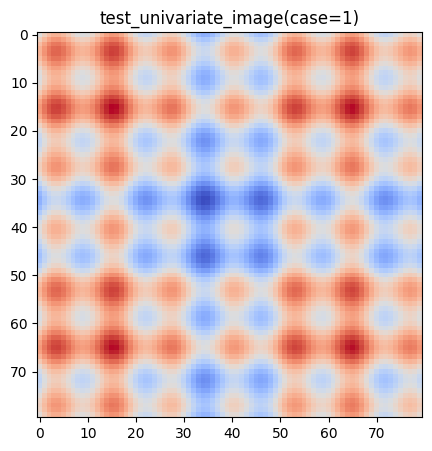

IMFs shape: (2, 80, 80)
max |reconstruction error|: 8.881784197001252e-16


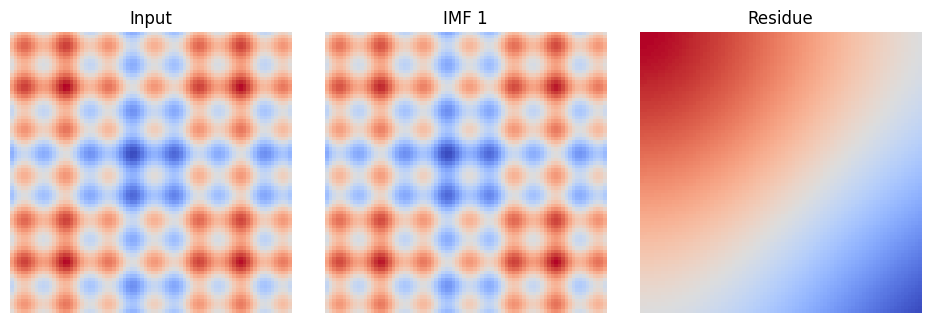

In [5]:
img = test_univariate_image(case=1, sampling_rate=80)
fig, ax = plot_grayscale_image(img, cmap="coolwarm")
ax.set_title("test_univariate_image(case=1)")
plt.show()

IMFs_lib = EMD2D(max_imfs=4, max_iter=60).fit_transform(img)
print("IMFs shape:", IMFs_lib.shape)
print("max |reconstruction error|:", np.max(np.abs(IMFs_lib.sum(0) - img)))

n_imf = IMFs_lib.shape[0]
fig, axes = plt.subplots(1, n_imf + 1, figsize=(3.2 * (n_imf + 1), 3.2))
axes[0].imshow(img, cmap="coolwarm")
axes[0].set_title("Input")
axes[0].axis("off")
for k, ax in enumerate(axes[1:]):
    title = f"IMF {k + 1}" if k < n_imf - 1 else "Residue"
    ax.imshow(IMFs_lib[k], cmap="coolwarm")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. Summary

- `EMD2D.fit_transform(image)` expects a 2-D array and returns `(K, H, W)`.
- Reconstruction: `IMFs.sum(axis=0)` matches the input (up to numerical error).
- For **multi-channel** images that must share scale indices, switch to
  `BMEMD` — see `examples/image/bmemd.ipynb`.
